In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#data cleaning
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna()

In [ ]:
df.shape

(7032, 21)

In [ ]:
#overall churn rate
churn_rate = (
    df['Churn']
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


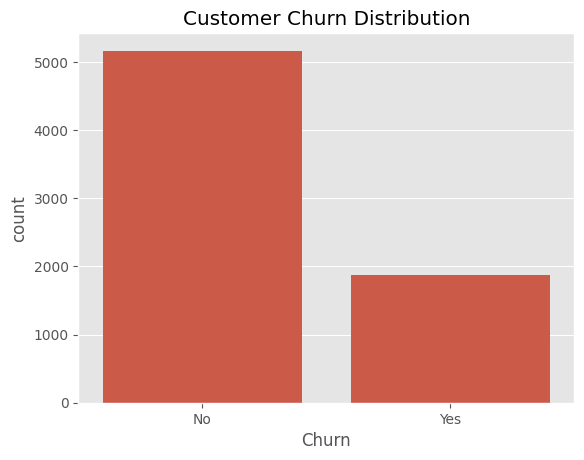

In [ ]:
sns.countplot(
    data=df,
    x='Churn'
)

plt.title('Customer Churn Distribution')
plt.show()

In [ ]:
#Churn by Contract Type
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


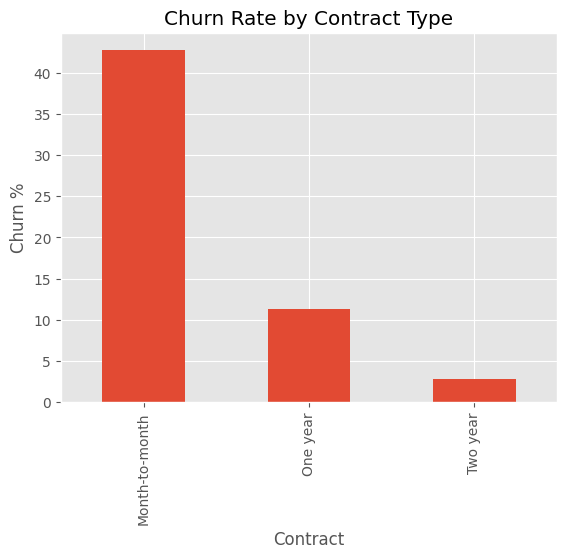

In [ ]:
contract_churn['Yes'].plot(
    kind='bar'
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn %')
plt.show()

In [ ]:
#Churn by Payment Method
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100



<Axes: ylabel='PaymentMethod'>

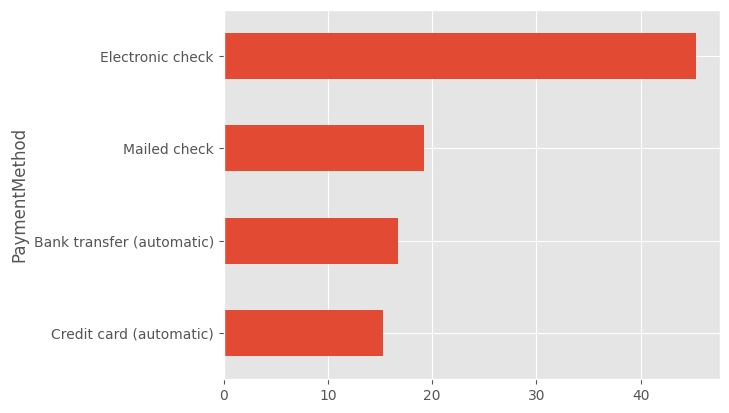

In [ ]:
payment_churn['Yes'].sort_values().plot(
    kind='barh'
)

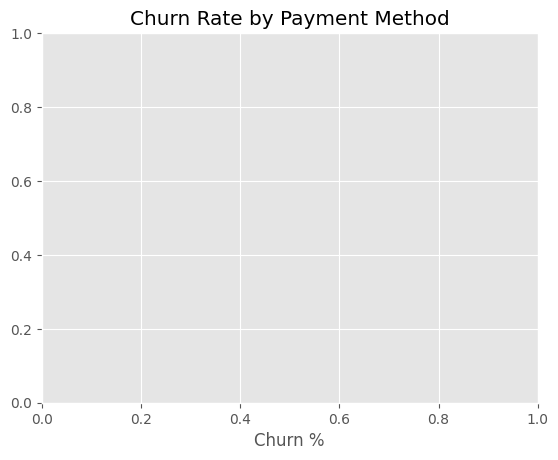

In [ ]:
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn %')
plt.show()

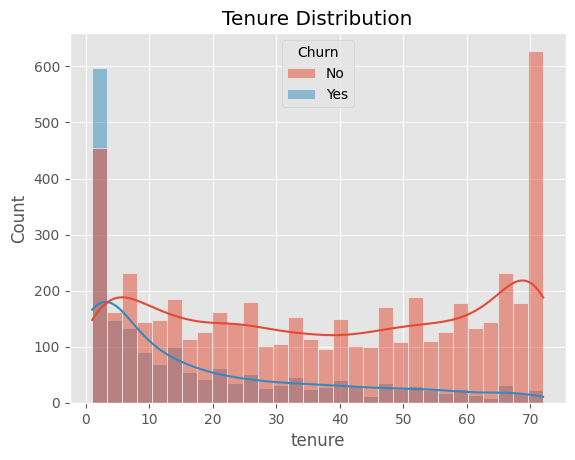

In [ ]:
#Tenure Analysis
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title('Tenure Distribution')
plt.show()

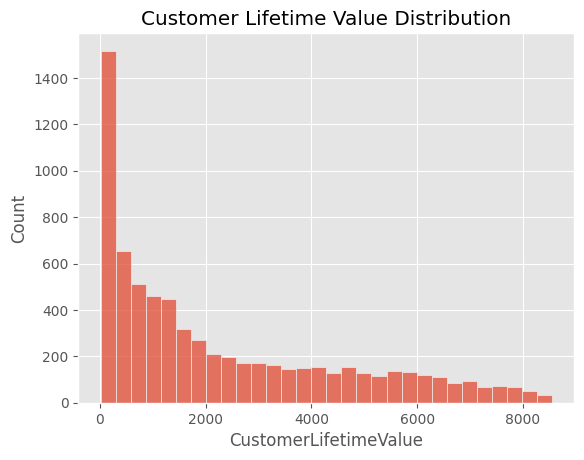

In [ ]:
#Customer Lifetime Value Analysis
df['CustomerLifetimeValue'] = (
    df['MonthlyCharges']
    * df['tenure']
)
df['CustomerLifetimeValue'].describe()
sns.histplot(
    df['CustomerLifetimeValue'],
    bins=30
)

plt.title('Customer Lifetime Value Distribution')
plt.show()

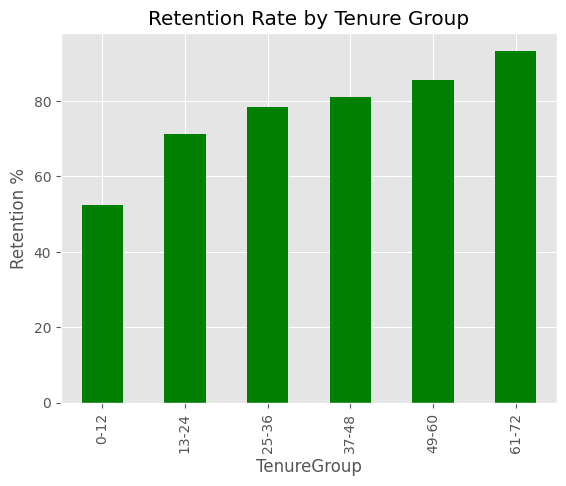

In [ ]:
#Retention Analysis
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,36,48,60,72],
    labels=[
        '0-12',
        '13-24',
        '25-36',
        '37-48',
        '49-60',
        '61-72'
    ]
)
retention = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

retention
retention['No'].plot(
    kind='bar',
    color='green'
)

plt.title('Retention Rate by Tenure Group')
plt.ylabel('Retention %')
plt.show()

In [ ]:
#print(churn_rate)
#contract_churn
#payment_churn
#retention
df['CustomerLifetimeValue'].describe()

,CustomerLifetimeValue
count,7032.000000
mean,2283.147248
std,2264.703327
min,18.800000
25%,397.800000
50%,1394.575000
75%,3791.250000
max,8550.000000


#Dashboard code

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

st.set_page_config(
    page_title="Customer Retention & Churn Dashboard",
    page_icon="📊",
    layout="wide"
)

@st.cache_data
def load_data():
    base_dir = os.path.dirname(__file__)
    file_path = os.path.join(base_dir, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

    df = pd.read_csv(file_path)

    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df = df.dropna()

    df["CustomerLifetimeValue"] = df["MonthlyCharges"] * df["tenure"]

    df["TenureGroup"] = pd.cut(
        df["tenure"],
        bins=[0,12,24,36,48,60,72],
        labels=["0-12","13-24","25-36","37-48","49-60","61-72"]
    )

    return df

df = load_data()

st.title("📊 Customer Retention & Churn Analysis Dashboard")

st.markdown("""
This dashboard analyzes customer churn patterns, retention drivers,
and customer lifetime trends for a subscription-based business.
""")

churn_rate = (df["Churn"] == "Yes").mean() * 100
retention_rate = (df["Churn"] == "No").mean() * 100
avg_clv = df["CustomerLifetimeValue"].mean()
avg_tenure = df["tenure"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Churn Rate", f"{churn_rate:.2f}%")
col2.metric("Retention Rate", f"{retention_rate:.2f}%")
col3.metric("Average CLV", f"${avg_clv:,.0f}")
col4.metric("Average Tenure", f"{avg_tenure:.1f} Months")

st.divider()

col1, col2 = st.columns(2)

with col1:
    st.subheader("Customer Churn Distribution")
    fig, ax = plt.subplots()
    sns.countplot(data=df, x="Churn", ax=ax)
    st.pyplot(fig)

with col2:
    st.subheader("Churn Rate by Contract Type")
    contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
    fig, ax = plt.subplots()
    contract_churn["Yes"].plot(kind="bar", ax=ax)
    ax.set_ylabel("Churn %")
    st.pyplot(fig)

col1, col2 = st.columns(2)

with col1:
    st.subheader("Churn Rate by Payment Method")
    payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
    fig, ax = plt.subplots()
    payment_churn["Yes"].sort_values().plot(kind="barh", ax=ax)
    ax.set_xlabel("Churn %")
    st.pyplot(fig)

with col2:
    st.subheader("Retention by Tenure Group")
    retention = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index") * 100
    fig, ax = plt.subplots()
    retention["No"].plot(kind="bar", ax=ax)
    ax.set_ylabel("Retention %")
    st.pyplot(fig)

col1, col2 = st.columns(2)

with col1:
    st.subheader("Tenure Distribution")
    fig, ax = plt.subplots()
    sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=ax)
    st.pyplot(fig)

with col2:
    st.subheader("Customer Lifetime Value Distribution")
    fig, ax = plt.subplots()
    sns.histplot(df["CustomerLifetimeValue"], bins=30, ax=ax)
    st.pyplot(fig)

st.divider()

st.header("Key Insights")

st.markdown("""
### Churn Patterns
- Overall churn rate is **26.58%**
- Month-to-month customers churn the most
- Electronic check users have the highest churn
- New customers are more likely to leave early

### Retention Drivers
- Long-term contracts improve retention
- Longer tenure increases loyalty
- Customers beyond 60 months rarely churn

### Customer Lifetime Trends
- Average CLV is approximately **$2,283**
- High tenure customers generate more value
- Early churn reduces lifetime revenue significantly
""")

st.header("Recommendations")

st.markdown("""
1. Encourage annual contracts with discounts
2. Improve onboarding in first 12 months
3. Target electronic check users with retention offers
4. Reward long-term customers
5. Identify high-risk users early
""")

with st.expander("View Dataset"):
    st.dataframe(df)

Overwriting app.py


In [ ]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
seaborn
numpy

Writing requirements.txt
